In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [85]:
titanic = sns.load_dataset("titanic")
titanic.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

#### PROMPT 1
Actúa como data scientist senior, experto en el uso de python para analitica de datos utilizando python, seaborn. 


voy a trabajar con un dataframe llamado titanic


y el resultado de titanica.dtypes es: 



survived          int64 pclass            int64 sex              object age             float64 sibsp             int64 parch             int64 fare            float64 embarked         object class          category who              object adult_male         bool deck           category embark_town      object alive            object alone              bool age_segment    category 



deseo que me ayudes con código en python para realizar mi análisis en tareas especificas que yo te solicite. 



In [24]:
titanic.shape

(784, 16)

In [25]:
titanic.sample(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_segment
834,0,3,male,18.0,0,0,8.30,S,Third,man,True,NaN,Southampton,no,True,Joven
45,0,3,male,NaN,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True,NaN


#### PROMPT 2: deseo evaluar la calidad de mis datos: 
ayudame identificando si hay filas duplicadas, y si hay valores nulos. 
cuantos nulos hay por cada columna, y que porcentaje representa sobre el total de valores de las columnas

In [27]:
# ── 1. FILAS DUPLICADAS ──────────────────────────────────────────────────────
n_duplicados = titanic.duplicated().sum()
print("=" * 50)
print("FILAS DUPLICADAS")
print("=" * 50)
print(f"  Total de filas     : {len(titanic)}")
print(f"  Filas duplicadas   : {n_duplicados}")
print(f"  Filas únicas       : {len(titanic) - n_duplicados}")

if n_duplicados > 0:
    print("\n  Detalle de duplicados:")
    print(titanic[titanic.duplicated(keep=False)])
else:
    print("\n  No se encontraron filas duplicadas.")

FILAS DUPLICADAS
  Total de filas     : 784
  Filas duplicadas   : 0
  Filas únicas       : 784

  No se encontraron filas duplicadas.


In [28]:

# ── 2. VALORES NULOS ─────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("VALORES NULOS POR COLUMNA")
print("=" * 50)

nulos = titanic.isnull().sum()
porcentaje = (nulos / len(titanic) * 100).round(2)

resumen_nulos = pd.DataFrame({
    "Nulos"      : nulos,
    "Total filas": len(titanic),
    "% Nulos"    : porcentaje
})

resumen_nulos = resumen_nulos[resumen_nulos["Nulos"] > 0].sort_values("% Nulos", ascending=False)

if resumen_nulos.empty:
    print("  No hay valores nulos en el dataset.")
else:
    print(resumen_nulos.to_string())


VALORES NULOS POR COLUMNA
             Nulos  Total filas  % Nulos
deck           582          784    74.23
age            106          784    13.52
age_segment    106          784    13.52
embarked         2          784     0.26
embark_town      2          784     0.26


In [29]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_segment
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,Joven
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Adulto
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Adulto
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Adulto
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,Adulto


#### PROMPT 3: ayudame graficando la distribución de la columna age. 
utilizando seaborn y graficamente una línea vertical con la media, y otra con la mediana. agrégale un título y nombre de ejes adecuados.

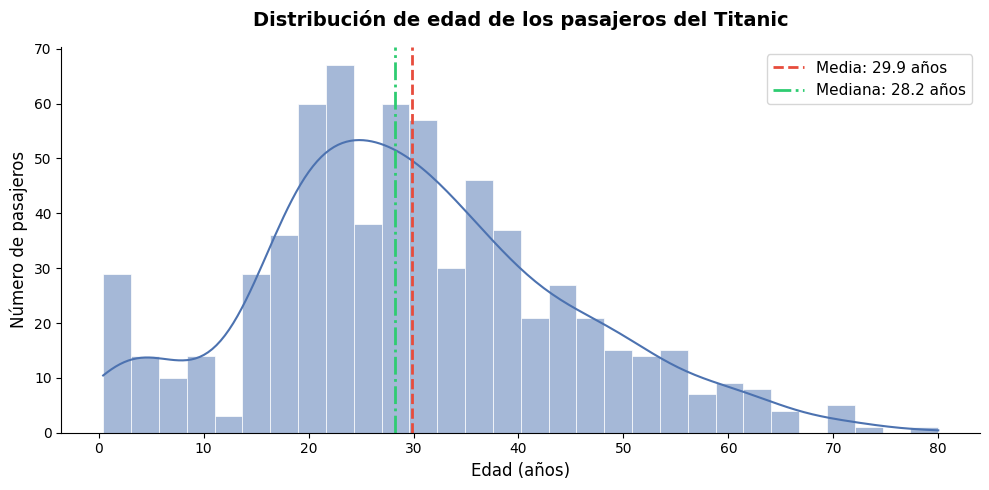

In [30]:
# ── Estadísticas ─────────────────────────────────────────────────────────────
media   = titanic["age"].mean()
mediana = titanic["age"].median()

# ── Gráfico ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=titanic,
    x="age",
    bins=30,
    kde=True,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.5,
    ax=ax
)

# Línea media
ax.axvline(media, color="#E74C3C", linestyle="--", linewidth=2, label=f"Media: {media:.1f} años")

# Línea mediana
ax.axvline(mediana, color="#2ECC71", linestyle="-.", linewidth=2, label=f"Mediana: {mediana:.1f} años")

# Títulos y ejes
ax.set_title("Distribución de edad de los pasajeros del Titanic", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Edad (años)", fontsize=12)
ax.set_ylabel("Número de pasajeros", fontsize=12)

ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

In [31]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_segment
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,Joven
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Adulto
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Adulto
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Adulto
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,Adulto


ahora hagamos el histógrama para la columna fare, nuevamente graficando la línea de media y la línea de mediana

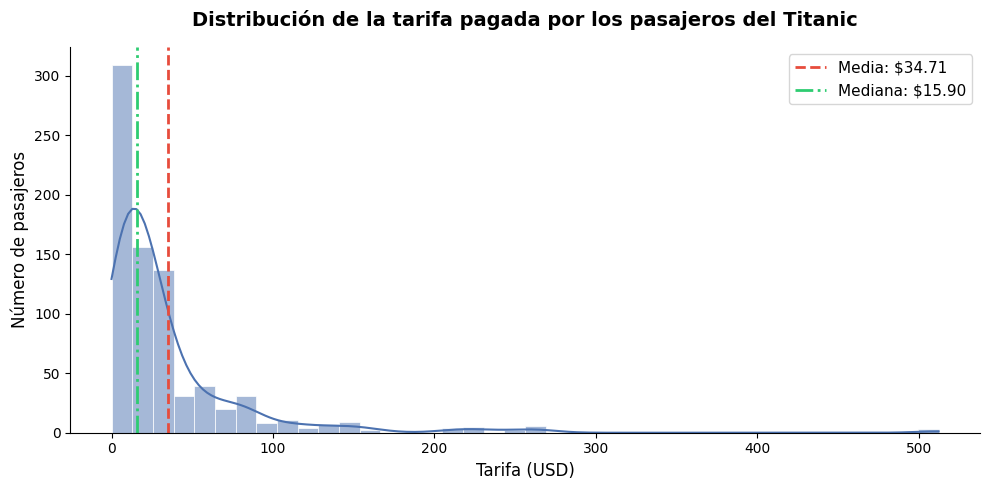

In [32]:
# ── Estadísticas ─────────────────────────────────────────────────────────────
media   = titanic["fare"].mean()
mediana = titanic["fare"].median()

# ── Gráfico ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=titanic,
    x="fare",
    bins=40,
    kde=True,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.5,
    ax=ax
)

# Línea media
ax.axvline(media, color="#E74C3C", linestyle="--", linewidth=2, label=f"Media: ${media:.2f}")

# Línea mediana
ax.axvline(mediana, color="#2ECC71", linestyle="-.", linewidth=2, label=f"Mediana: ${mediana:.2f}")

# Títulos y ejes
ax.set_title("Distribución de la tarifa pagada por los pasajeros del Titanic", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Tarifa (USD)", fontsize=12)
ax.set_ylabel("Número de pasajeros", fontsize=12)

ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

Ahora deseo ver un countplot de las columnas: sexo y class. 
manejemos con subplots para tener dos gráficas una alado de la otra. 
Utilizando seaborn

/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_25657/4150454441.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_25657/4150454441.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Masculino", "Femenino"], fontsize=11)
/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_25657/4150454441.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_25657/4150454441.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ti

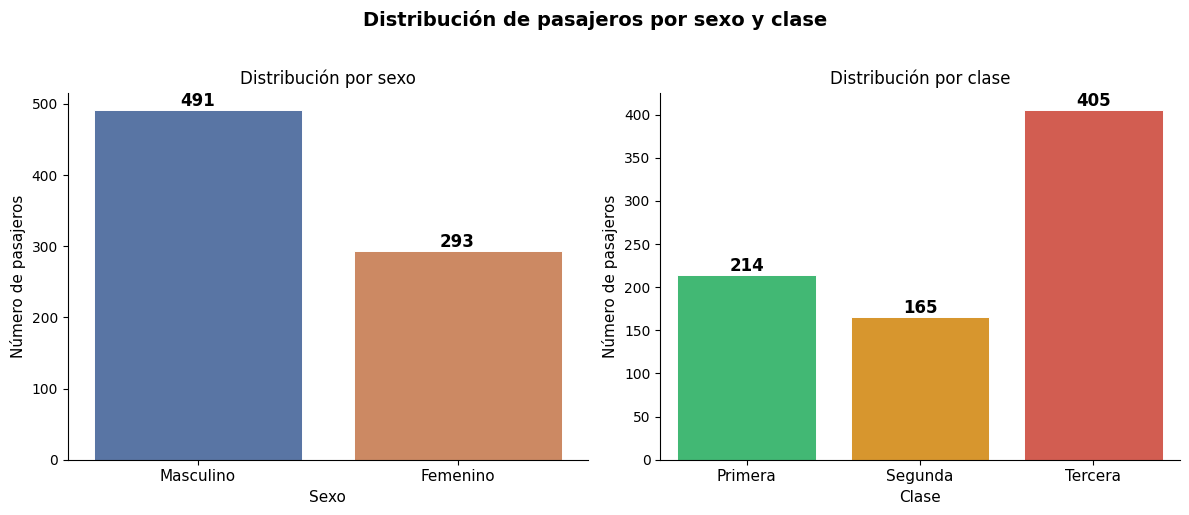

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# ── Gráfico ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distribución de pasajeros por sexo y clase", fontsize=14, fontweight="bold", y=1.02)

# ── Subplot 1: Sexo ───────────────────────────────────────────────────────────
sns.countplot(
    data=titanic,
    x="sex",
    palette={"male": "#4C72B0", "female": "#DD8452"},
    edgecolor="white",
    linewidth=0.7,
    ax=axes[0]
)
axes[0].set_title("Distribución por sexo", fontsize=12)
axes[0].set_xlabel("Sexo", fontsize=11)
axes[0].set_ylabel("Número de pasajeros", fontsize=11)
axes[0].set_xticklabels(["Masculino", "Femenino"], fontsize=11)

for bar in axes[0].patches:
    axes[0].annotate(
        f'{int(bar.get_height())}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )

# ── Subplot 2: Clase ──────────────────────────────────────────────────────────
sns.countplot(
    data=titanic,
    x="class",
    palette={"First": "#2ECC71", "Second": "#F39C12", "Third": "#E74C3C"},
    edgecolor="white",
    linewidth=0.7,
    order=["First", "Second", "Third"],
    ax=axes[1]
)
axes[1].set_title("Distribución por clase", fontsize=12)
axes[1].set_xlabel("Clase", fontsize=11)
axes[1].set_ylabel("Número de pasajeros", fontsize=11)
axes[1].set_xticklabels(["Primera", "Segunda", "Tercera"], fontsize=11)

for bar in axes[1].patches:
    axes[1].annotate(
        f'{int(bar.get_height())}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

In [35]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_segment
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,Joven
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Adulto
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Adulto
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Adulto
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,Adulto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False,Adulto
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,Joven
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,NaN
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,Adulto


create una nueva columna que se llame: age_segment y tenga segméntos de edades. Quisiera rangos: niños, jóvenes, adulto, y adulto mayor. 
¿Que intervalos usarías en cada uno de estos segméntos?

P: ¿Los intervalos te parecen adecuados?  
R: Sí, usar esos intervalos. 
P: ¿Cómo manejamos los valores nulos en age?  
R: Asignarles la categoría 'Desconocido'. 

In [36]:
# ── Crear columna age_segment ─────────────────────────────────────────────────
bins   = [0, 12, 25, 59, 120]
labels = ["Niño", "Joven", "Adulto", "Adulto mayor"]

titanic["age_segment"] = pd.cut(
    titanic["age"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

# ── Manejo de nulos → 'Desconocido' ──────────────────────────────────────────
titanic["age_segment"] = (
    titanic["age_segment"]
    .cat.add_categories("Desconocido")
    .fillna("Desconocido")
)

In [39]:
# ¿si sobrevivieron más mujeres o más hombres?

Deseo conocer si dentro de mi dataset cual es el % de supervivencia de hombres y de mujeres dentro de mi dataset. 
utiliza las columnas sex y survived. 
Y me gustaría ver el resultado en un barplot de seaborn. 
 deseo que encima de cada barra se encuentre el porcentaje de supervivencia, con un tamaño adecuado. 
no deseo que se visualice el axis Y, quiero una gráfica limpia.


      sex  pct_survived
0  female          74.1
1    male          21.6


/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_25657/1870185178.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_25657/1870185178.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Femenino", "Masculino"], fontsize=12)


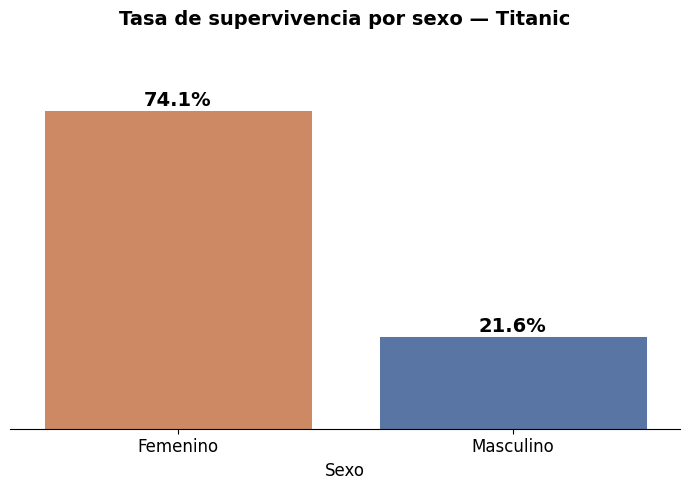

In [40]:
# ── Cálculo del % de supervivencia por sexo ───────────────────────────────────
survival_sex = (
    titanic.groupby("sex")["survived"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
    .rename(columns={"survived": "pct_survived"})
)

print(survival_sex)

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

sns.barplot(
    data=survival_sex,
    x="sex",
    y="pct_survived",
    palette={"male": "#4C72B0", "female": "#DD8452"},
    edgecolor="white",
    linewidth=0.7,
    ax=ax
)

# ── Etiquetas encima de cada barra ────────────────────────────────────────────
for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height():.1f}%',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom",
        fontsize=14, fontweight="bold",
        color="black"
    )

# ── Títulos y ejes ────────────────────────────────────────────────────────────
ax.set_title("Tasa de supervivencia por sexo — Titanic", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Sexo", fontsize=12)
ax.set_xticklabels(["Femenino", "Masculino"], fontsize=12)

# ── Gráfica limpia: sin eje Y ─────────────────────────────────────────────────
ax.yaxis.set_visible(False)
ax.set_ylabel("")
ax.set_ylim(0, survival_sex["pct_survived"].max() + 15)

sns.despine(left=True)
plt.tight_layout()
plt.show()

In [41]:
# Supervivencia por clase
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_segment
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,Joven
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Adulto
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Adulto
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Adulto
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,Adulto


    class  pct_survived
0   First          63.1
1  Second          50.9
2   Third          25.7


/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_25657/779873199.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby("class")["survived"]
/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_25657/779873199.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_25657/779873199.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Primera", "Segunda", "Tercera"], fontsize=12)


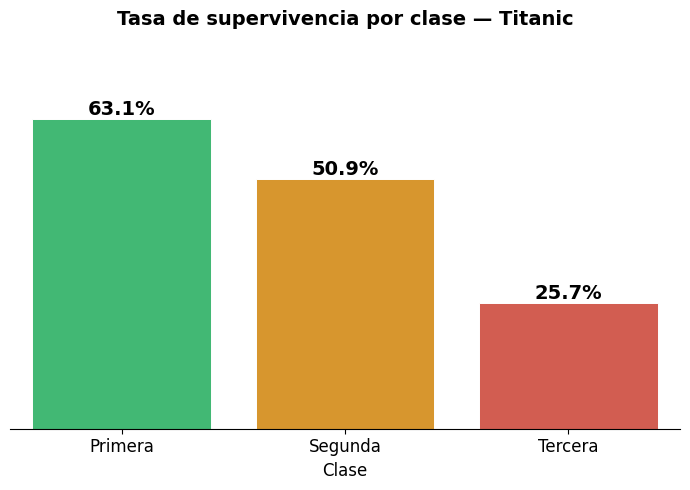

In [42]:
# ── Cálculo del % de supervivencia por clase ──────────────────────────────────
survival_class = (
    titanic.groupby("class")["survived"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
    .rename(columns={"survived": "pct_survived"})
)

print(survival_class)

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

sns.barplot(
    data=survival_class,
    x="class",
    y="pct_survived",
    order=["First", "Second", "Third"],
    palette={"First": "#2ECC71", "Second": "#F39C12", "Third": "#E74C3C"},
    edgecolor="white",
    linewidth=0.7,
    ax=ax
)

# ── Etiquetas encima de cada barra ────────────────────────────────────────────
for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height():.1f}%',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom",
        fontsize=14, fontweight="bold",
        color="black"
    )

# ── Títulos y ejes ────────────────────────────────────────────────────────────
ax.set_title("Tasa de supervivencia por clase — Titanic", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Clase", fontsize=12)
ax.set_xticklabels(["Primera", "Segunda", "Tercera"], fontsize=12)

# ── Gráfica limpia: sin eje Y ─────────────────────────────────────────────────
ax.yaxis.set_visible(False)
ax.set_ylabel("")
ax.set_ylim(0, survival_class["pct_survived"].max() + 15)

sns.despine(left=True)
plt.tight_layout()
plt.show()

    class     sex  pct_survived
0   First  female          96.8
1   First    male          37.2
2  Second  female          91.8
3  Second    male          18.5
4   Third  female          47.2
5   Third    male          15.8


/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_25657/745010590.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby(["class", "sex"])["survived"]
/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_25657/745010590.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Primera", "Segunda", "Tercera"], fontsize=12)


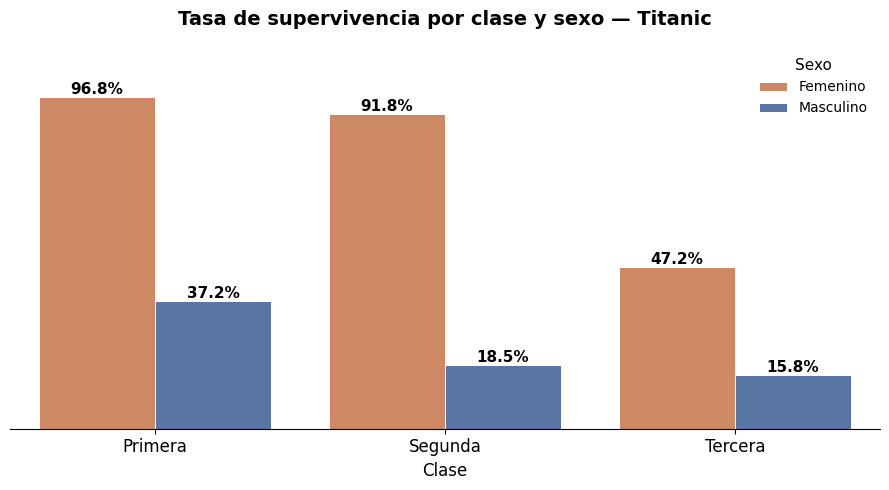

In [43]:
# ── Cálculo del % de supervivencia por clase y sexo ───────────────────────────
survival_class_sex = (
    titanic.groupby(["class", "sex"])["survived"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
    .rename(columns={"survived": "pct_survived"})
)

print(survival_class_sex)

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=survival_class_sex,
    x="class",
    y="pct_survived",
    hue="sex",
    order=["First", "Second", "Third"],
    hue_order=["female", "male"],
    palette={"female": "#DD8452", "male": "#4C72B0"},
    edgecolor="white",
    linewidth=0.7,
    ax=ax
)

# ── Etiquetas encima de cada barra ────────────────────────────────────────────
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%',
            (bar.get_x() + bar.get_width() / 2, height),
            ha="center", va="bottom",
            fontsize=11, fontweight="bold",
            color="black"
        )

# ── Títulos y ejes ────────────────────────────────────────────────────────────
ax.set_title("Tasa de supervivencia por clase y sexo — Titanic", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Clase", fontsize=12)
ax.set_xticklabels(["Primera", "Segunda", "Tercera"], fontsize=12)

# ── Leyenda ───────────────────────────────────────────────────────────────────
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, ["Femenino", "Masculino"],
    title="Sexo", title_fontsize=11,
    fontsize=10, frameon=False
)

# ── Gráfica limpia: sin eje Y ─────────────────────────────────────────────────
ax.yaxis.set_visible(False)
ax.set_ylabel("")
ax.set_ylim(0, survival_class_sex["pct_survived"].max() + 15)

sns.despine(left=True)
plt.tight_layout()
plt.show()

Me gustaría ver un heapmap que cruce las variables: age_segment, y sex. 
Y que el valor sea el % de supervivencia.

In [48]:
survival_heatmap

Sexo,Femenino,Masculino
age_segment,,
Niño,58,57
Joven,75,13
Adulto,78,22
Adulto mayor,100,14
Desconocido,68,20


Me gustaría ver un heatmap que cruce las variables: age_segment, y sex. 
Y que el valor sea el % de supervivencia.

Me gustaría que cada valor este redondéalo a entero, y que muestre el símbolo de %

/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_25657/28476544.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby(["age_segment", "sex"])["survived"]
/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_25657/28476544.py:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  labels = survival_heatmap.applymap(lambda v: f"{v}%")


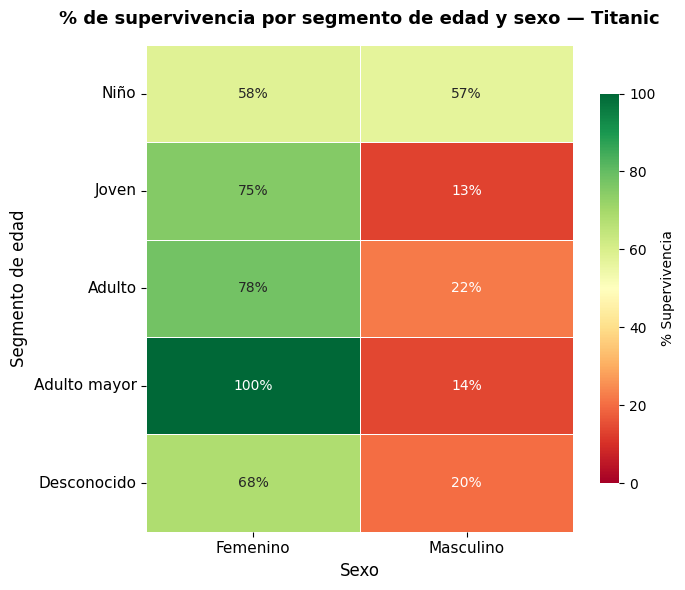

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ── Cálculo del % de supervivencia por age_segment y sex ─────────────────────
survival_heatmap = (
    titanic.groupby(["age_segment", "sex"])["survived"]
    .mean()
    .mul(100)
    .round(0)
    .astype(int)
    .unstack(level="sex")
)

# ── Ordenar filas por segmento lógico ─────────────────────────────────────────
orden = ["Niño", "Joven", "Adulto", "Adulto mayor", "Desconocido"]
survival_heatmap = survival_heatmap.reindex(orden)

survival_heatmap.columns.name = "Sexo"
survival_heatmap = survival_heatmap.rename(columns={"female": "Femenino", "male": "Masculino"})

# ── Etiquetas con símbolo % ───────────────────────────────────────────────────
labels = survival_heatmap.applymap(lambda v: f"{v}%")

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    survival_heatmap,
    annot=labels,
    fmt="",
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "% Supervivencia", "shrink": 0.8},
    vmin=0,
    vmax=100,
    ax=ax
)

# ── Títulos y ejes ────────────────────────────────────────────────────────────
ax.set_title("% de supervivencia por segmento de edad y sexo — Titanic",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Sexo", fontsize=12)
ax.set_ylabel("Segmento de edad", fontsize=12)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11, rotation=0)

plt.tight_layout()
plt.show()

Me gustaría identificar los outliers de la columna fare, utilizando el método de IQR, con ello crear un nuevo dataset que contenga a estos outliers.

In [49]:

Q1  = titanic["fare"].quantile(0.25)
Q3  = titanic["fare"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

titanic_outliers = titanic[
    (titanic["fare"] < limite_inferior) |
    (titanic["fare"] > limite_superior)
].copy()


In [50]:
titanic_outliers

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_segment
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,C,Southampton,no,False,Joven
31,1,1,female,NaN,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False,Desconocido
34,0,1,male,28.0,1,0,82.1708,C,First,man,True,NaN,Cherbourg,no,False,Adulto
52,1,1,female,49.0,1,0,76.7292,C,First,woman,False,D,Cherbourg,yes,False,Adulto
61,1,1,female,38.0,0,0,80.0000,NaN,First,woman,False,B,NaN,yes,True,Adulto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
829,1,1,female,62.0,0,0,80.0000,NaN,First,woman,False,B,NaN,yes,True,Adulto mayor
835,1,1,female,39.0,1,1,83.1583,C,First,woman,False,E,Cherbourg,yes,False,Adulto
849,1,1,female,NaN,1,0,89.1042,C,First,woman,False,C,Cherbourg,yes,False,Desconocido
856,1,1,female,45.0,1,1,164.8667,S,First,woman,False,NaN,Southampton,yes,False,Adulto


Necesito ver un gráfico de dispersión entre age y fare. 
Me gustatía abajo del título que se me muestre la correlación entre estas dos columnas

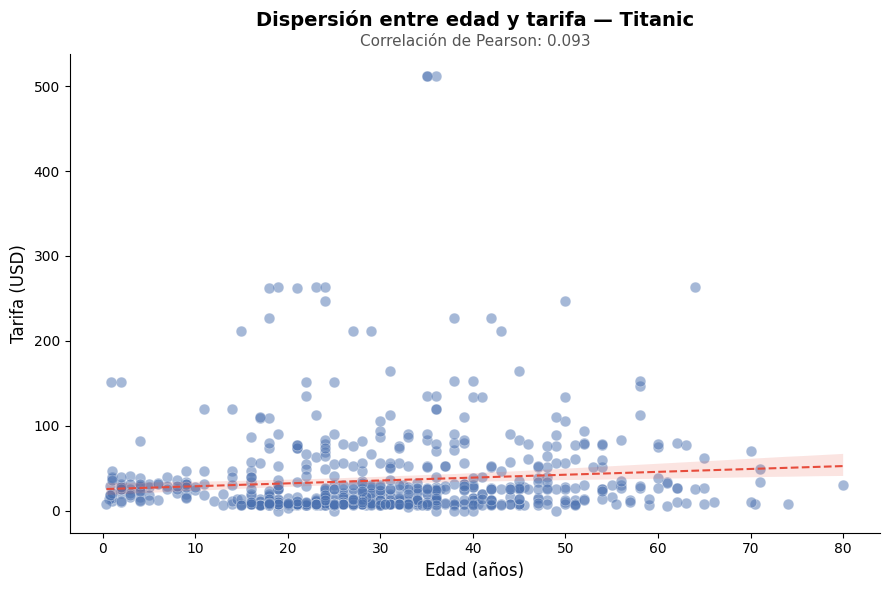

In [54]:
# ── Correlación ───────────────────────────────────────────────────────────────
correlacion = titanic["age"].corr(titanic["fare"]).round(3)

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=titanic,
    x="age",
    y="fare",
    alpha=0.5,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.4,
    s=60,
    ax=ax
)

# ── Línea de tendencia ────────────────────────────────────────────────────────
sns.regplot(
    data=titanic,
    x="age",
    y="fare",
    scatter=False,
    color="#E74C3C",
    line_kws={"linewidth": 1.5, "linestyle": "--"},
    ax=ax
)

# ── Título con correlación como subtítulo ─────────────────────────────────────
ax.set_title(
    "Dispersión entre edad y tarifa — Titanic",
    fontsize=14, fontweight="bold", pad=20
)
ax.text(
    0.5, 1.01,
    f"Correlación de Pearson: {correlacion}",
    transform=ax.transAxes,
    ha="center", va="bottom",
    fontsize=11, color="#555555"
)

# ── Ejes ──────────────────────────────────────────────────────────────────────
ax.set_xlabel("Edad (años)", fontsize=12)
ax.set_ylabel("Tarifa (USD)", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

In [56]:
titanic["family_size"] = titanic["sibsp"] + titanic["parch"] + 1

   family_size  pct_survived
0            1          33.6
1            2          55.2
2            3          57.4
3            4          71.4
4            5          23.1
5            6          13.6
6            7          33.3
7            8           0.0
8           11           0.0


/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_25657/2910433429.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


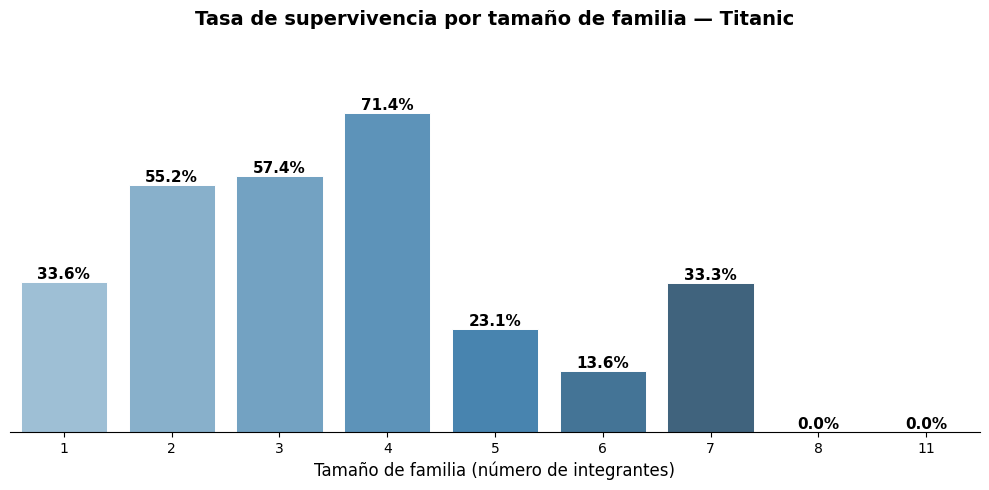

In [57]:
# ── Cálculo del % de supervivencia por family_size ────────────────────────────
survival_family = (
    titanic.groupby("family_size")["survived"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
    .rename(columns={"survived": "pct_survived"})
)

print(survival_family)

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=survival_family,
    x="family_size",
    y="pct_survived",
    palette="Blues_d",
    edgecolor="white",
    linewidth=0.7,
    ax=ax
)

# ── Etiquetas encima de cada barra ────────────────────────────────────────────
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{height:.1f}%',
        (bar.get_x() + bar.get_width() / 2, height),
        ha="center", va="bottom",
        fontsize=11, fontweight="bold",
        color="black"
    )

# ── Títulos y ejes ────────────────────────────────────────────────────────────
ax.set_title("Tasa de supervivencia por tamaño de familia — Titanic",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Tamaño de familia (número de integrantes)", fontsize=12)

# ── Gráfica limpia: sin eje Y ─────────────────────────────────────────────────
ax.yaxis.set_visible(False)
ax.set_ylabel("")
ax.set_ylim(0, survival_family["pct_survived"].max() + 15)

sns.despine(left=True)
plt.tight_layout()
plt.show()

In [58]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_segment,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,Joven,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Adulto,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Adulto,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Adulto,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,Adulto,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False,Adulto,6
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,Joven,1
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,Desconocido,4
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,Adulto,1


In [ ]:
titanic.embark_town.value_counts()

embark_town
Southampton    568
Cherbourg      155
Queenstown      59
Name: count, dtype: int64

   embark_town  total_survived
2  Southampton             211
0    Cherbourg              90
1   Queenstown              20


/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_25657/2195368540.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


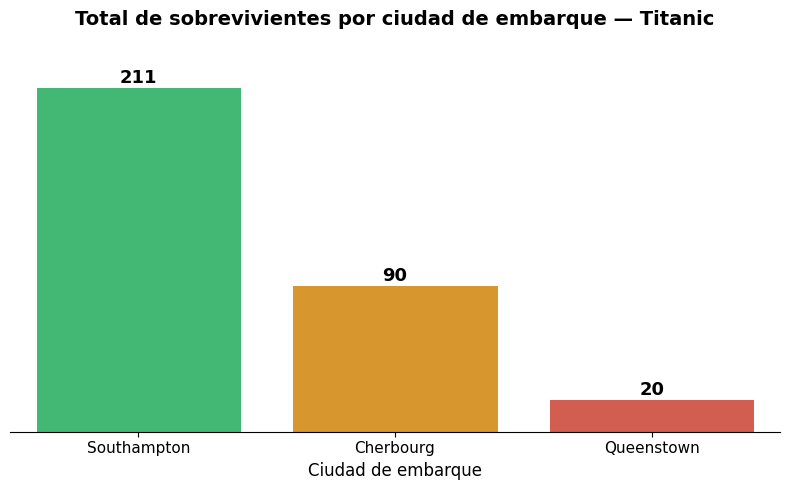

In [59]:
# ── Cálculo de sobrevivientes por ciudad de embarque ─────────────────────────
survival_town = (
    titanic.groupby("embark_town")["survived"]
    .sum()
    .reset_index()
    .rename(columns={"survived": "total_survived"})
    .sort_values("total_survived", ascending=False)
)

print(survival_town)

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=survival_town,
    x="embark_town",
    y="total_survived",
    palette=["#2ECC71", "#F39C12", "#E74C3C"],
    edgecolor="white",
    linewidth=0.7,
    ax=ax
)

# ── Etiquetas encima de cada barra ────────────────────────────────────────────
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha="center", va="bottom",
        fontsize=13, fontweight="bold",
        color="black"
    )

# ── Títulos y ejes ────────────────────────────────────────────────────────────
ax.set_title("Total de sobrevivientes por ciudad de embarque — Titanic",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Ciudad de embarque", fontsize=12)
ax.tick_params(axis="x", labelsize=11)

# ── Gráfica limpia: sin eje Y ─────────────────────────────────────────────────
ax.yaxis.set_visible(False)
ax.set_ylabel("")
ax.set_ylim(0, survival_town["total_survived"].max() + 25)

sns.despine(left=True)
plt.tight_layout()
plt.show()

PROMPT: Pero necesito ver el % de supervivencia por cada ciudad de embarque

   embark_town  pct_survived
0    Cherbourg          58.1
2  Southampton          37.1
1   Queenstown          33.9


/var/folders/fk/cw9x2jm11l73gzjg4n26v5y00000gn/T/ipykernel_25657/1721039546.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<module 'seaborn' from '/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/__init__.py'>

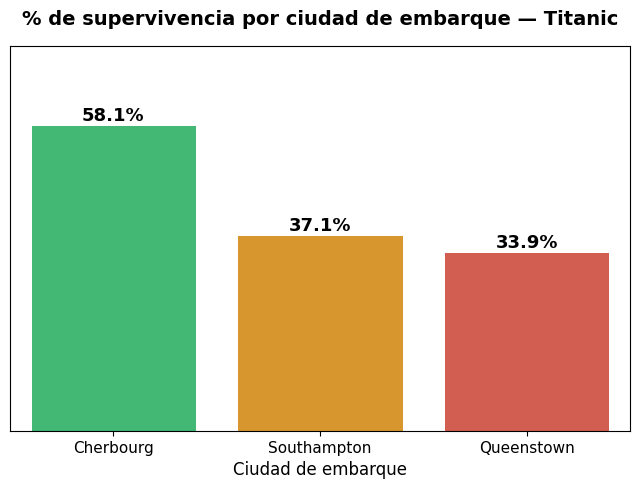

In [61]:

# ── Cálculo del % de supervivencia por ciudad de embarque ────────────────────
survival_town = (
    titanic.groupby("embark_town")["survived"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
    .rename(columns={"survived": "pct_survived"})
    .sort_values("pct_survived", ascending=False)
)

print(survival_town)

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=survival_town,
    x="embark_town",
    y="pct_survived",
    palette=["#2ECC71", "#F39C12", "#E74C3C"],
    edgecolor="white",
    linewidth=0.7,
    order=survival_town["embark_town"],
    ax=ax
)

# ── Etiquetas encima de cada barra ────────────────────────────────────────────
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{height:.1f}%',
        (bar.get_x() + bar.get_width() / 2, height),
        ha="center", va="bottom",
        fontsize=13, fontweight="bold",
        color="black"
    )

# ── Títulos y ejes ────────────────────────────────────────────────────────────
ax.set_title("% de supervivencia por ciudad de embarque — Titanic",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Ciudad de embarque", fontsize=12)
ax.tick_params(axis="x", labelsize=11)

# ── Gráfica limpia: sin eje Y ─────────────────────────────────────────────────
ax.yaxis.set_visible(False)
ax.set_ylabel("")
ax.set_ylim(0, survival_town["pct_survived"].max() + 15)

sns

In [ ]:
titanic
# Imputar nulos (missing values)
# Imputar outliers
# transformar ciertas columnas
# Codificar las varibles de texto


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_segment,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,Joven,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Adulto,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Adulto,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Adulto,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,Adulto,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False,Adulto,6
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,Joven,1
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,Desconocido,4
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,Adulto,1


In [66]:
titanic.groupby(["sex"])["age"].median()

sex
female    27.0
male      29.0
Name: age, dtype: float64

In [ ]:
titanic
## Es una forma de rellenar valores vacíos pero no siempre es la mejor
mediana = titanic["age"].median()

# rellenarlo con promedio
# rellenarlo con mediana

0      22.00
1      38.00
2      26.00
3      35.00
4      35.00
       ...  
885    39.00
887    19.00
888    28.25
889    26.00
890    32.00
Name: age, Length: 784, dtype: float64

PROMPT: Deseo rellenar los missing values de la columna age, utilizando la mediana de acuerdo al sexo correspondiente.

In [67]:
# ── Mediana de age por sexo ───────────────────────────────────────────────────
mediana_por_sexo = titanic.groupby("sex")["age"].median()
print("Mediana de edad por sexo:")
print(mediana_por_sexo)

# ── Nulos antes del relleno ───────────────────────────────────────────────────
nulos_antes = titanic["age"].isnull().sum()
print(f"\nValores nulos en 'age' antes : {nulos_antes}")

# ── Imputación con mediana por sexo ──────────────────────────────────────────
titanic["age"] = titanic.groupby("sex")["age"].transform(
    lambda x: x.fillna(x.median())
)

# ── Nulos después del relleno ─────────────────────────────────────────────────
nulos_despues = titanic["age"].isnull().sum()
print(f"Valores nulos en 'age' después: {nulos_despues}")

# ── Verificación ──────────────────────────────────────────────────────────────
print("\nEstadísticas de 'age' tras imputación:")
print(titanic.groupby("sex")["age"].describe().round(2))

Mediana de edad por sexo:
sex
female    27.0
male      29.0
Name: age, dtype: float64

Valores nulos en 'age' antes : 106
Valores nulos en 'age' después: 0

Estadísticas de 'age' tras imputación:
        count   mean    std   min   25%   50%   75%   max
sex                                                      
female  293.0  27.83  13.16  0.75  19.0  27.0  35.0  63.0
male    491.0  30.75  13.97  0.42  22.0  29.0  37.0  80.0


In [70]:
titanic["age_segment"].fillna("Desconocido", inplace = True)

# Moda (En caso de pocos Na : El valor más frecuente)
# Crear la categoría desconocido 

In [72]:
#titanic = titanic.drop_duplicates()
#titanic.drop_duplicates(inplace = True)

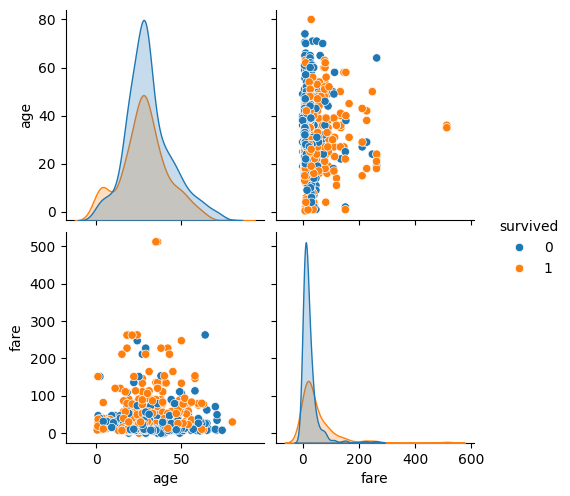

In [76]:
sns.pairplot(titanic[["age", "fare", "survived"]], hue = "survived")

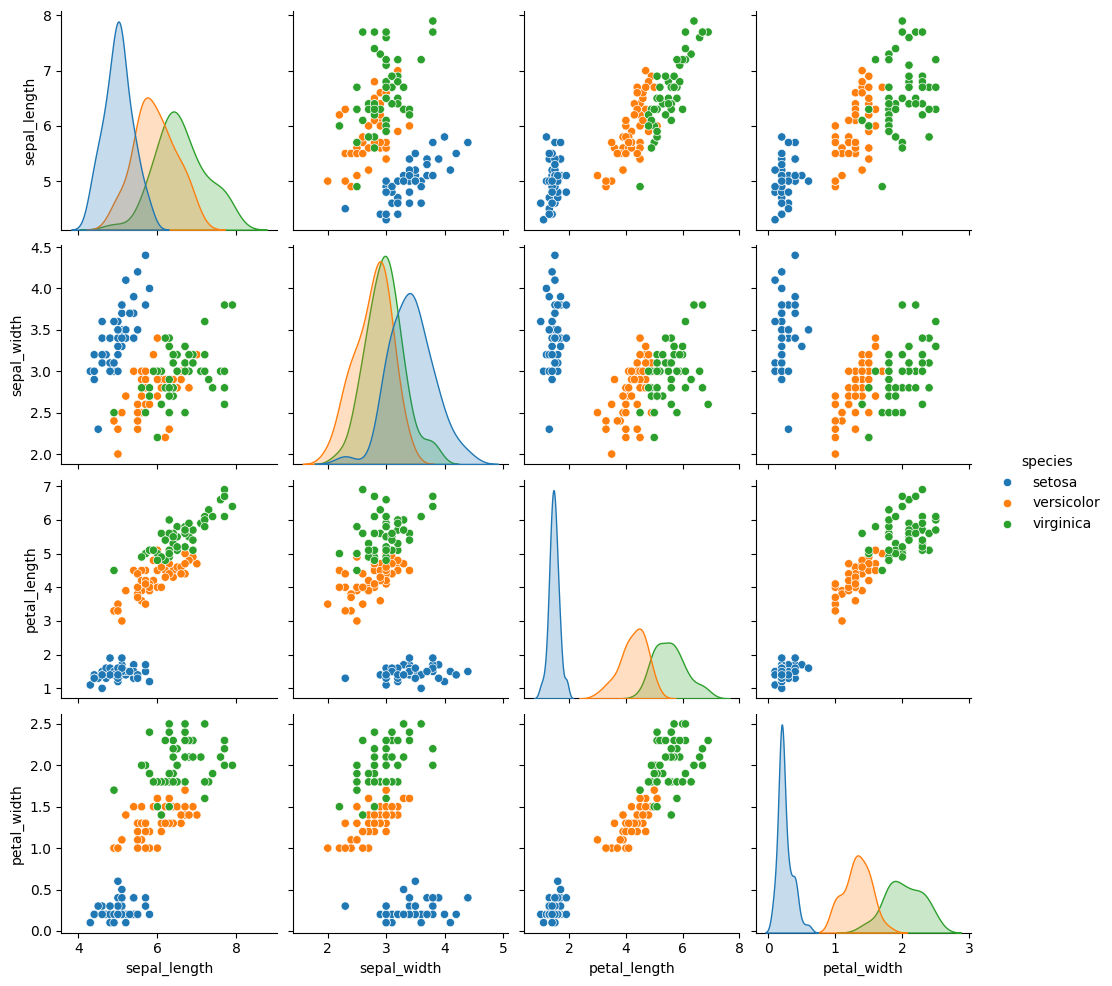

In [ ]:
#iris = sns.load_dataset("iris")
## NUEVA GRÁFICA
#sns.pairplot(iris, hue = "species")